#Prohlášení
Tento notebook slouží ke trénování modelů s architekturou BERT a byl vytvořen z velké části na základě noteboků Nielse Rogge, repozitář: https://github.com/NielsRogge/Transformers-Tutorials

#Proměnné prostředí

In [1]:
!git clone https://github.com/TomasFAV/InvoiceCzech.git /content/InvoiceCzech

Cloning into '/content/InvoiceCzech'...
remote: Enumerating objects: 545, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 545 (delta 69), reused 103 (delta 38), pack-reused 398 (from 1)
Receiving objects: 100% (545/545), 40.02 MiB | 16.87 MiB/s, done.
Resolving deltas: 100% (121/121), done.


In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
FINETUNED_MODEL_ID = "TomasFAV/BERTInvoiceCzechV0R"
BASE_MODEL_ID = "google-bert/bert-base-multilingual-cased" #BASE pro V0
#BASE_MODEL_ID = "TomasFAV/BERTInvoiceCzechV012"

In [3]:
!pip install -q evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00


#Načtení datasetů

In [4]:
from datasets import load_dataset

train_dataset = load_dataset("TomasFAV/DocumentInvoiceCzechNameEntityRecognitionV0", split="train")
val_dataset = load_dataset("TomasFAV/RealDocumentInvoiceCzechNameEntityRecognition", split="train") #jedná se o dataset reálných faktur anotovaných pro NER úlohu
val_json_dataset = load_dataset("TomasFAV/RealDocumentInvoiceCzech", split="train")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/272M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1200 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/13.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/39 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/39 [00:00<?, ? examples/s]

#Id2Label
Vytváří se na základě třídy ClassLabel Huggingface datasetu

In [5]:
from datasets.features import ClassLabel

features = train_dataset.features
column_names = train_dataset.column_names
label_column_name = "ner_tags"

if isinstance(features[label_column_name].feature, ClassLabel):
    label_list = features[label_column_name].feature.names
    # No need to convert the labels since they are already ints.
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}

#Processor a model

In [6]:
from transformers import AutoProcessor
from transformers import BertForTokenClassification

processor = AutoProcessor.from_pretrained(BASE_MODEL_ID)
model = BertForTokenClassification.from_pretrained(BASE_MODEL_ID,
                                                         id2label=id2label,
                                                         label2id=label2id).to(device)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params we

#Vizualizace datasetu
Slouží pro kontrolu

In [7]:
from PIL import ImageDraw, ImageFont, Image
import random

In [8]:
item = train_dataset[0]

In [9]:
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n))) #vygeneruje random barvy pro jednotlivé NER tagy
colors = get_colors(len(label_list))
font = ImageFont.load_default()
label2color = {label: colors[idx] for idx, label in enumerate(label_list)}

In [10]:
image = item["image"]
ner_tags = item["ner_tags"]
tokens = item["tokens"]
boxes = item["bboxes"]

In [11]:
draw_1 = ImageDraw.Draw(image, "RGBA")

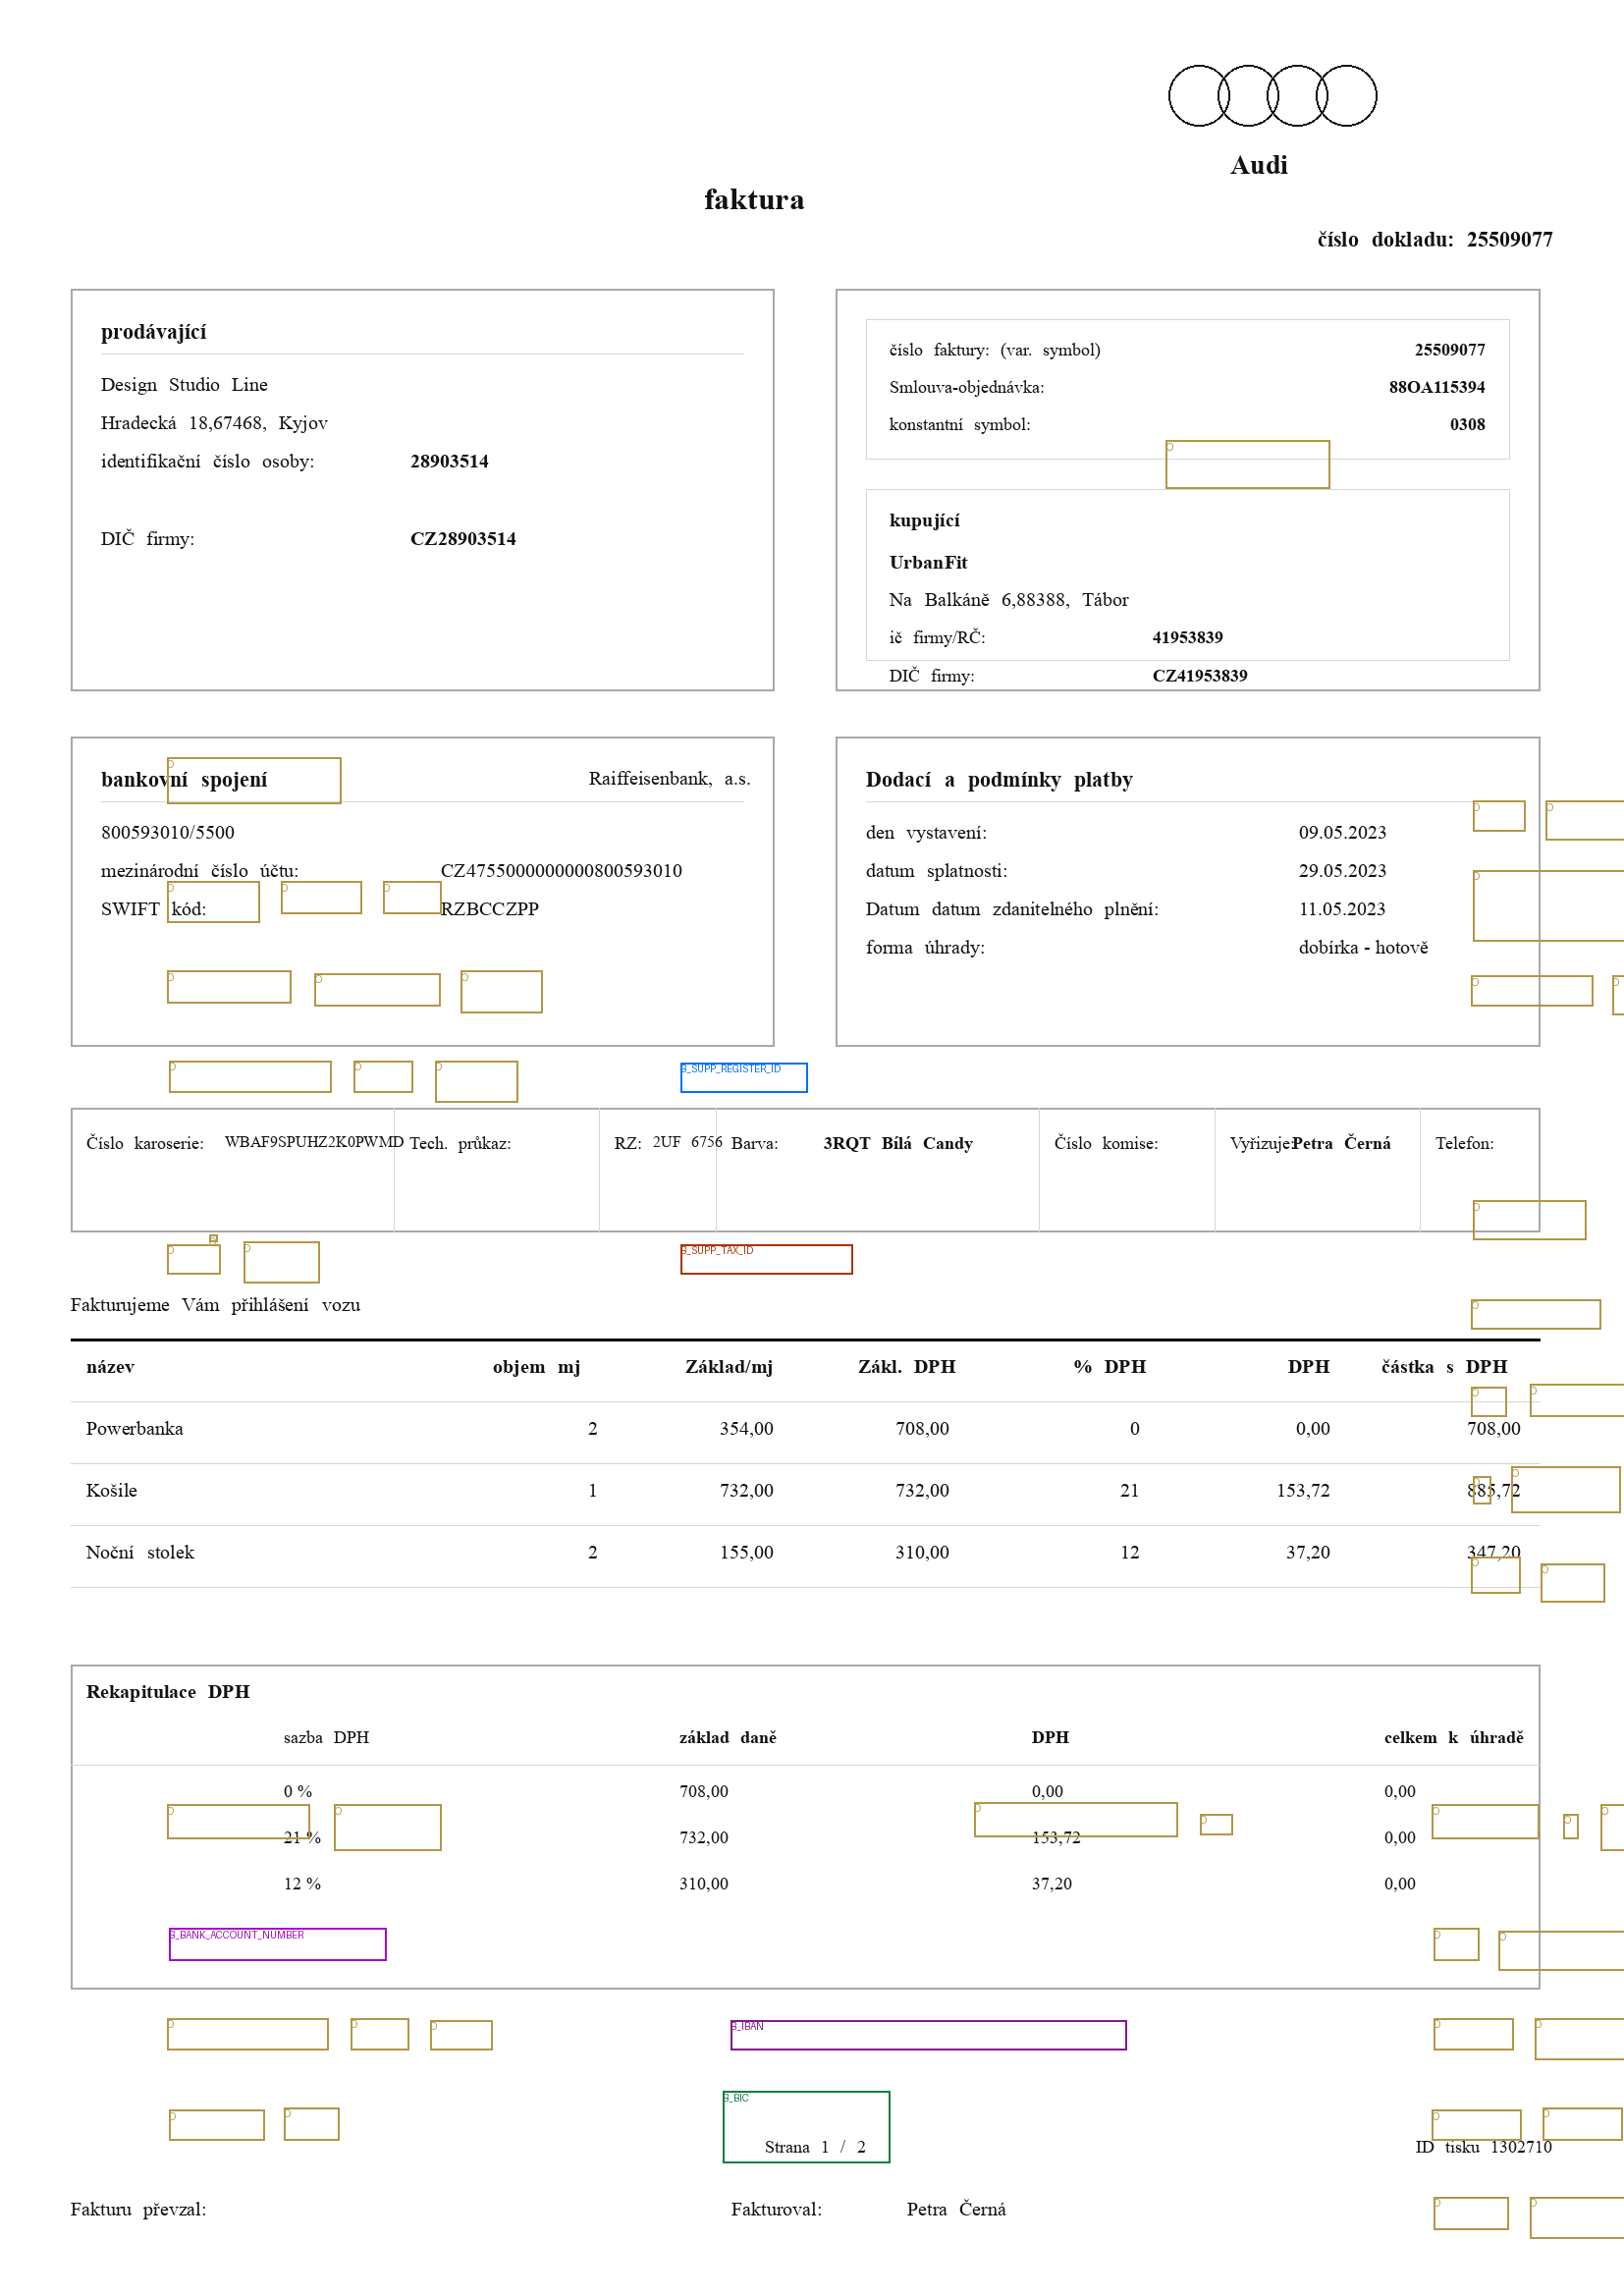

In [12]:
# We are visulizing boxes on original imag
for label_id, box in zip(ner_tags, boxes):
    x1, y1, x2, y2 = box
    box = [x1/1000 * image.width, y1/1000 * image.height, x2/1000 * image.width, y2/1000 * image.height]

    draw_1.rectangle(box, outline=label2color[id2label[label_id]], width=2)
    draw_1.text((box[0], box[1]), id2label[label_id], fill=label2color[id2label[label_id]], font=font, size=20)

image

# Collator funkce

### Slouží pouze k přemapování datasetu, aby šel použít huggingface trainer!!!

In [13]:
from collections import defaultdict

def collate(batch):
    all_input_ids = []
    all_attention_mask = []
    all_token_type_ids = []
    all_labels = []

    for batch_idx in range(len(batch["tokens"])):
        tokens = batch["tokens"][batch_idx]
        tags = batch["ner_tags"][batch_idx]

        tokenized_inputs = processor(
            tokens,
            is_split_into_words=True,
            padding="max_length",
            truncation=True,
            max_length=512,
            stride=128,
            return_overflowing_tokens=True,
            add_special_tokens=True,
            return_offsets_mapping=True,
        )

        #Pro každý segment z původního vzorku
        for page_idx in range(len(tokenized_inputs["input_ids"])):
            word_ids = tokenized_inputs.word_ids(batch_index=page_idx)
            label_ids = []
            previous_word_idx = None # Inicializace pro každý segment
            for word_idx in word_ids:
                if word_idx is None: # Speciální token == IGNORE_ID => ignorace při tréninku
                    label_ids.append(-100)
                else:
                    label_ids.append(tags[word_idx])

            all_input_ids.append(tokenized_inputs["input_ids"][page_idx])
            all_attention_mask.append(tokenized_inputs["attention_mask"][page_idx])
            all_token_type_ids.append(tokenized_inputs["token_type_ids"][page_idx])
            all_labels.append(label_ids)

    # Vrací slovník, kde každá hodnota je list všech segmentů
    return {
        "input_ids": all_input_ids, #[[input_ids... prvního segmentu], [input_ids... druhého segmentu], ...]
        "attention_mask": all_attention_mask,
        "token_type_ids": all_token_type_ids,
        "labels": all_labels,
    }

In [14]:
from datasets import Features, Sequence, ClassLabel, Value, Array2D, Array3D

#NUTNÉ JINAK NEJDE POUŽÍT S HUGGINGFACE treninkovou API
features = Features({
    'input_ids': Sequence(feature=Value(dtype='int64')),
    'attention_mask': Sequence(feature=Value(dtype='int64')),
    'token_type_ids': Sequence(feature=Value(dtype='int64')),
    'labels': Sequence(feature=Value(dtype='int64')),
})

train_dataset_maped = train_dataset.map(
    collate,
    features=features,
    batched=True,
    remove_columns=train_dataset.column_names,
)

val_dataset_maped = val_dataset.map(
    collate,
    features=features,
    batched=True,
    remove_columns=val_dataset.column_names,
)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/39 [00:00<?, ? examples/s]

#Metriky

In [15]:
from evaluate import load
metric = load("seqeval")

In [16]:
import numpy as np

return_entity_level_metrics = False

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove ignored index (special tokens)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


#Trénink

In [17]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
                                    num_train_epochs=10,

                                    save_total_limit=2,
                                    output_dir=FINETUNED_MODEL_ID,
                                    per_device_train_batch_size=16,               # Batch size for training
                                    per_device_eval_batch_size=2,                # Batch size for evaluation
                                    learning_rate=1e-5,                          # Learning rate for the optimizer


                                    eval_strategy="epoch",
                                    save_strategy="epoch",

                                    load_best_model_at_end=True,                 # Load the best model when finished training
                                    metric_for_best_model="f1",            # Use accuracy as the metric to compare models
                                    greater_is_better = True,                     # Indicate whether the metric is to be maximized or minimized
                                    warmup_ratio=0.1, # we warmup a bit
                                    fp16=True, # we use mixed precision (less memory consumption)

                                    push_to_hub=True, # after training, we'd like to push our model to the hub
                                    hub_model_id=FINETUNED_MODEL_ID, # this is the name we'll use for our model on the hub,
                                    report_to="tensorboard"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [18]:
from transformers.data.data_collator import default_data_collator

# Initialize our Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_maped,
    eval_dataset=val_dataset_maped,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.383903,0.245070,0.294369,0.267466,0.904672
2,No log,0.285133,0.426784,0.490097,0.456255,0.925448
3,No log,0.282027,0.452005,0.577864,0.507244,0.927691
4,No log,0.302157,0.464286,0.636117,0.536785,0.925285
5,No log,0.300870,0.517681,0.693592,0.592863,0.931755
6,0.336745,0.327879,0.468085,0.649320,0.544005,0.925123
7,0.336745,0.311144,0.517699,0.681553,0.588433,0.934259
8,0.336745,0.319997,0.499270,0.664466,0.570143,0.931235
9,0.336745,0.326302,0.502422,0.684660,0.579553,0.930162
10,0.336745,0.323602,0.500432,0.674951,0.574735,0.930487


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=870, training_loss=0.20609228528779128, metrics={'train_runtime': 296.6351, 'train_samples_per_second': 46.859, 'train_steps_per_second': 2.933, 'total_flos': 3632977189171200.0, 'train_loss': 0.20609228528779128, 'epoch': 10.0})

#Evaluace
Nutná pro automatickou tvorbu model card na huggingface hubu

In [20]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

{'eval_loss': 0.30091652274131775,
 'eval_precision': 0.5182714617169374,
 'eval_recall': 0.6939805825242719,
 'eval_f1': 0.5933919973435166,
 'eval_accuracy': 0.9318529115323341,
 'eval_runtime': 1.0614,
 'eval_samples_per_second': 72.547,
 'eval_steps_per_second': 36.744,
 'epoch': 10.0}

# PUSH TO HUB

In [21]:
trainer.save_model(FINETUNED_MODEL_ID)
processor.save_pretrained(FINETUNED_MODEL_ID)

# Save processor and create model card
trainer.create_model_card()
trainer.push_to_hub()
processor.push_to_hub(repo_id=FINETUNED_MODEL_ID)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...zechV0R/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

...

  ...zechV0R/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...zechV0R/model.safetensors:  21%|##1       |  152MB /  709MB            

README.md: 0.00B [00:00, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/TomasFAV/BERTInvoiceCzechV0R/commit/842b011f15ad88314ca94755695002588c69c694', commit_message='Upload tokenizer', commit_description='', oid='842b011f15ad88314ca94755695002588c69c694', pr_url=None, repo_url=RepoUrl('https://huggingface.co/TomasFAV/BERTInvoiceCzechV0R', endpoint='https://huggingface.co', repo_type='model', repo_id='TomasFAV/BERTInvoiceCzechV0R'), pr_revision=None, pr_num=None)

# Interference

In [22]:
from transformers import AutoProcessor
from transformers import BertForTokenClassification

processor = AutoProcessor.from_pretrained(FINETUNED_MODEL_ID)
model = BertForTokenClassification.from_pretrained(FINETUNED_MODEL_ID,
                                                         id2label=id2label,
                                                         label2id=label2id).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [23]:
test_sample = val_dataset[2]
image = test_sample["image"]

In [24]:
words = test_sample["tokens"]
word_labels = test_sample["ner_tags"]
token_boxes = test_sample["bboxes"]

encoding = processor(
            words,
            is_split_into_words=True,
            padding="max_length",
            truncation=True,
            max_length=512,
            stride=128,
            return_overflowing_tokens=True,
            add_special_tokens=True,
            return_offsets_mapping=True,
            return_tensors="pt"
        )

offset_mapping = encoding.pop('offset_mapping')

overflow_to_sample_mapping = encoding.pop('overflow_to_sample_mapping')

for k,v in encoding.items():
  print(k,v.shape)
  encoding[k] = v.to(device)

input_ids torch.Size([3, 512])
token_type_ids torch.Size([3, 512])
attention_mask torch.Size([3, 512])


In [25]:
outputs = model(**encoding)

In [26]:
logits = outputs.logits
predictions = logits.view(1, -1, logits.size(2)).squeeze(0).argmax(-1)
predictions.shape

torch.Size([1536])

In [27]:
predictions = predictions.tolist()

width, height = image.size

In [28]:
word_ids = []
for batch_idx in range(len(encoding["input_ids"])):
    for id, word_id in enumerate(encoding.word_ids(batch_index=batch_idx)):
        word_ids.append(word_id)

In [29]:
import numpy as np

is_subword = np.array(offset_mapping.view(1, -1, offset_mapping.size(2)).squeeze(0).tolist())[:,0] != 0


true_words = [word_ids[idx] for idx, pred in enumerate(predictions) if not is_subword[idx]]
true_predictions = [id2label[pred] for idx, pred in enumerate(predictions) if not is_subword[idx]]
true_boxes = token_boxes

In [30]:
predicts = []
already_used_words = set()

for word, prediction in zip(true_words, true_predictions):
    if(word == None):
        continue
    if(word in already_used_words):
        continue
    already_used_words.add(word)
    predicts.append((words[word], prediction, true_boxes[word]))

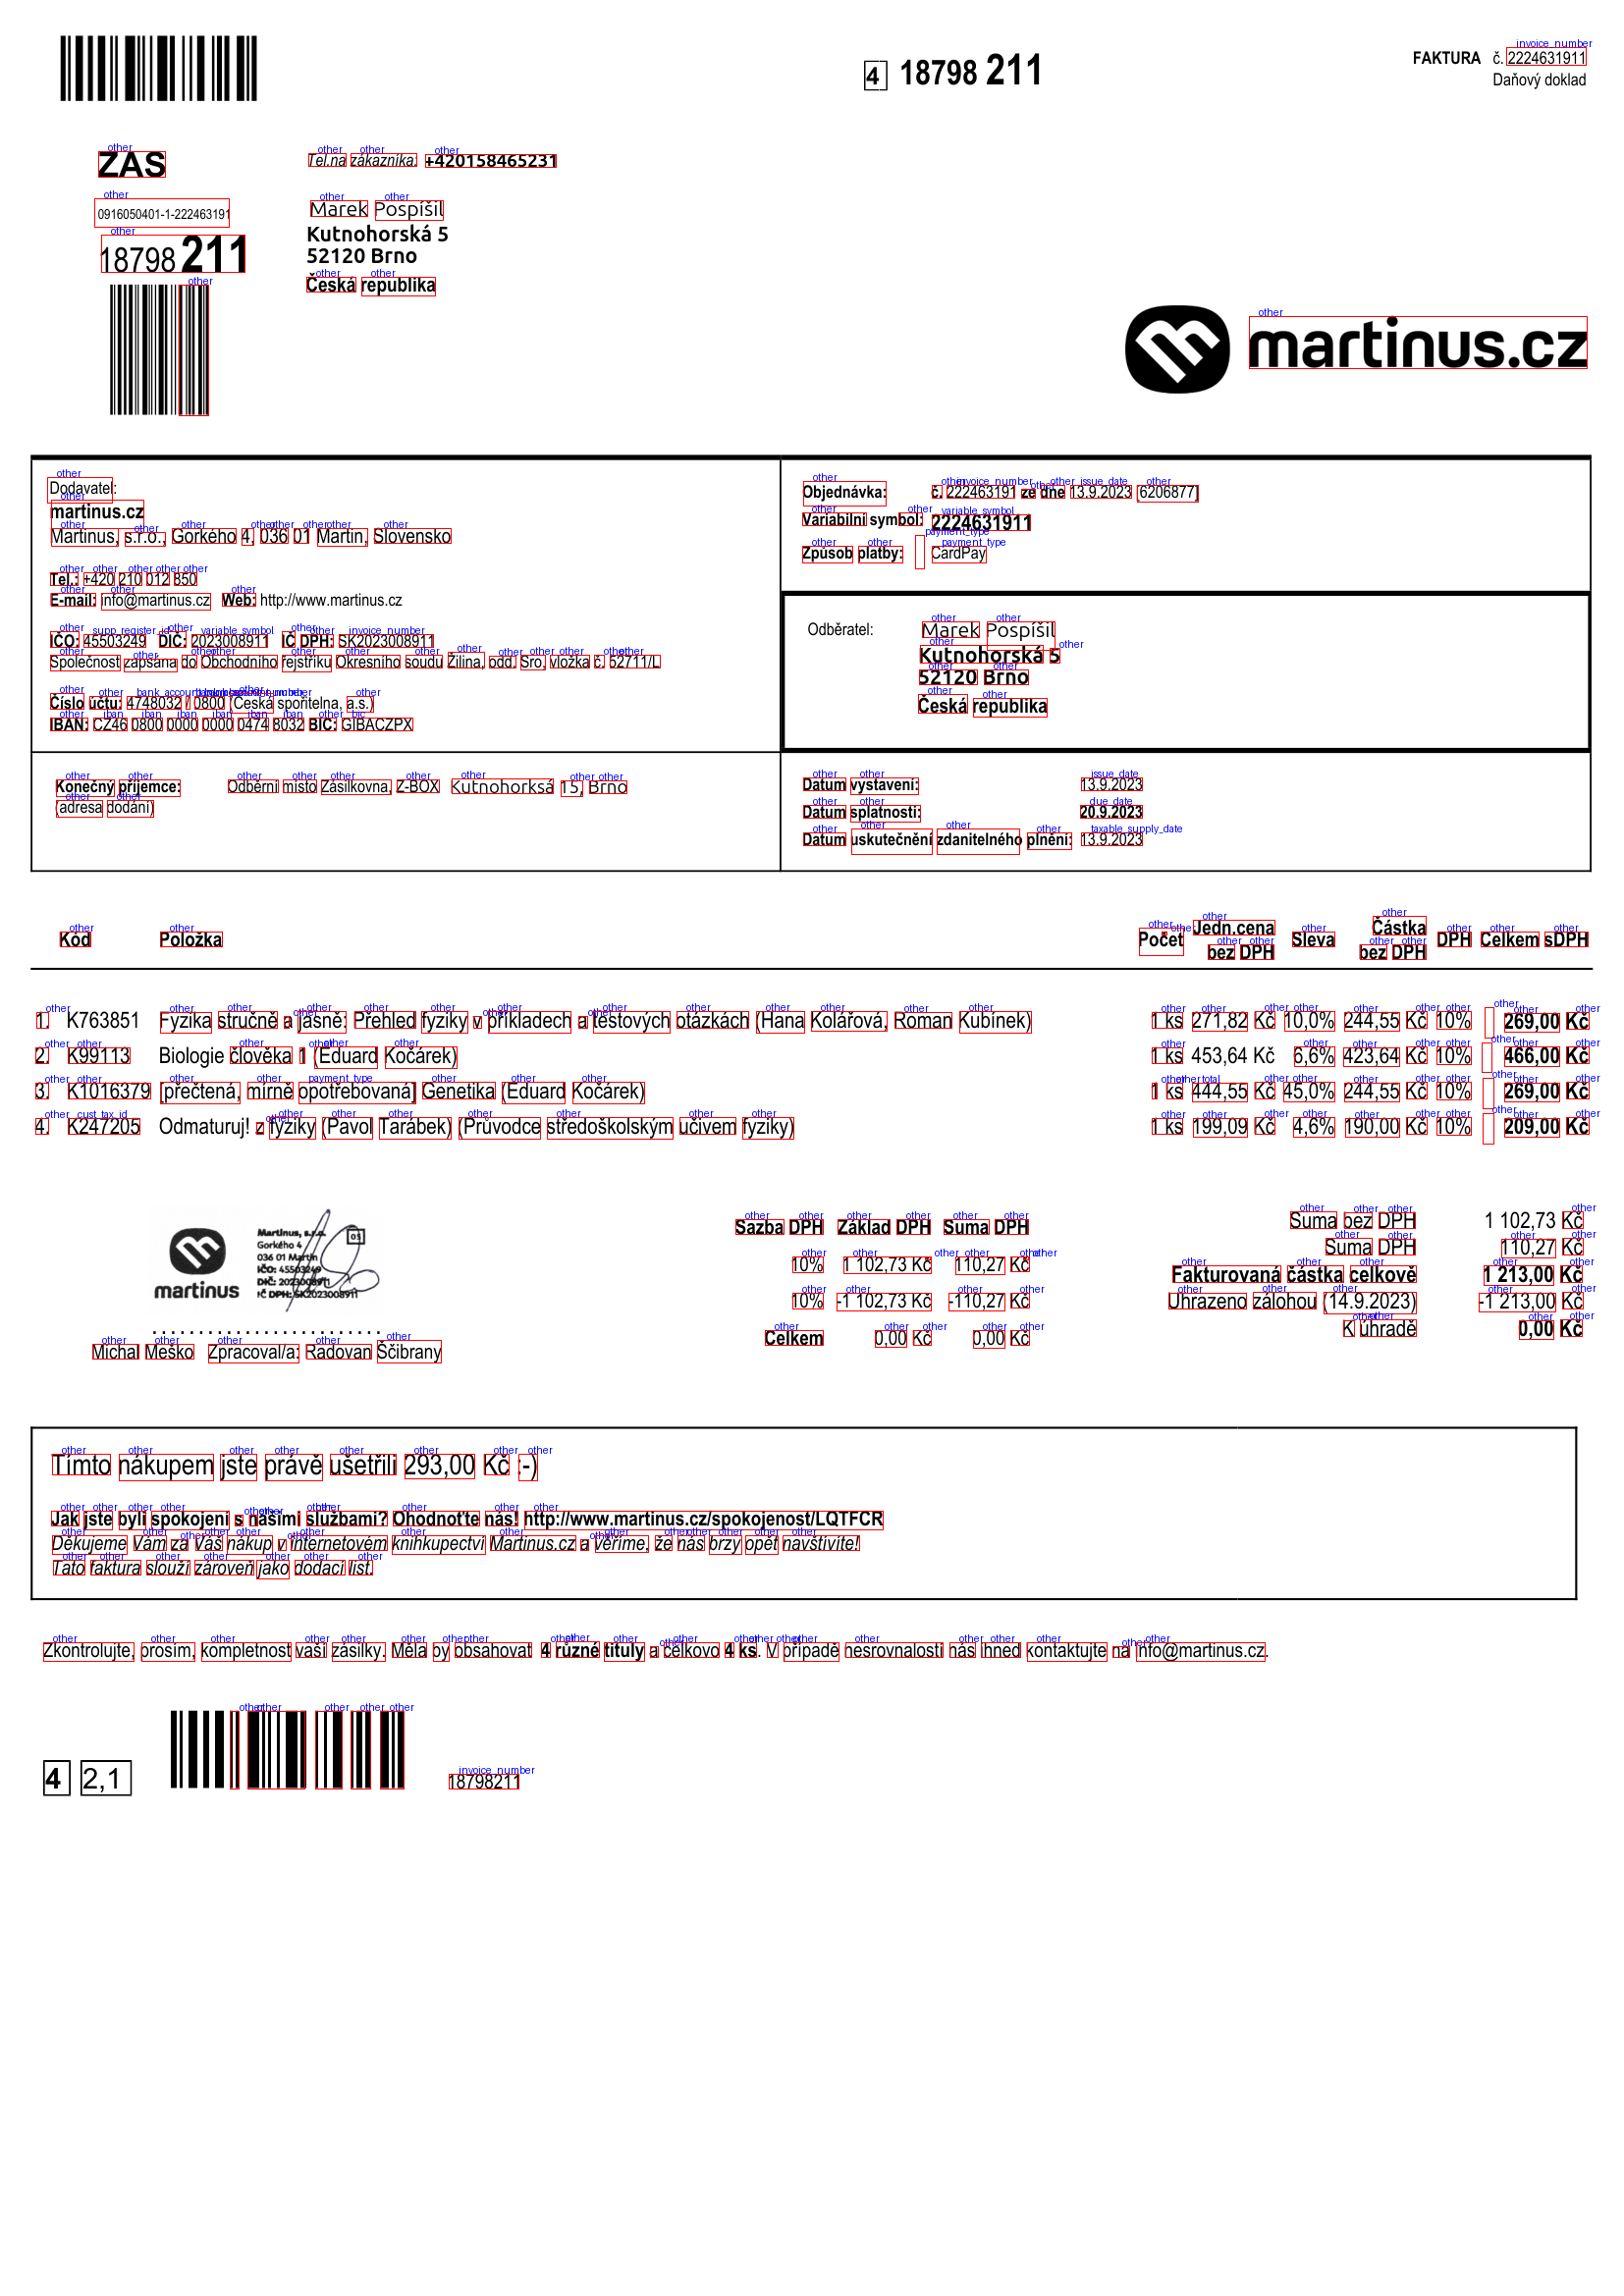

In [31]:
from PIL import ImageDraw, ImageFont

draw = ImageDraw.Draw(image)

font = ImageFont.load_default()

def iob_to_label(label):
    label = label[2:]
    if not label:
      return 'other'
    return label

for word, prediction, box in predicts:
    predicted_label = iob_to_label(prediction).lower()
    draw.rectangle(box, outline="red")
    draw.text((box[0] + 10, box[1] - 10), text=predicted_label, fill="blue", font=font)

image

In [32]:
image.save("faktura.jpg")

OSError: cannot write mode RGBA as JPEG